# U6 — Probability & Statistics (Part 2): Lab

**Probability & Information Theory** — axioms

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


#1. Probability theory & axioms

In [2]:

rolls = np.random.randint(1, 7, size=100_000)
p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


 LAB EXERCISE 1 — Probability by simulation

Simulate flipping **two coins** 100,000 times (`0 = tails, 1 = heads`):
1. Estimate `P(both heads)`.
2. Estimate `P(at least one head)`.
3. Check the addition idea: does `P(0 heads) + P(1 head) + P(2 heads)` sum to 1?

In [4]:
import numpy as np
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)
p_both_heads = np.mean(heads == 2)
print("P(both heads):", p_both_heads)
p_at_least_one = np.mean(heads >= 1)
print("P(at least one head):", p_at_least_one)
p_0_heads = np.mean(heads == 0)
p_1_head = np.mean(heads == 1)
p_2_heads = np.mean(heads == 2)
total = p_0_heads + p_1_head + p_2_heads
print("P(0 heads):", p_0_heads)
print("P(1 head):", p_1_head)
print("P(2 heads):", p_2_heads)
print("Sum:", total)

P(both heads): 0.25198
P(at least one head): 0.74932
P(0 heads): 0.25068
P(1 head): 0.49734
P(2 heads): 0.25198
Sum: 1.0


#2. Conditional probability & independence

In [5]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [6]:

A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


 LAB EXERCISE 2 — Conditional probability

Using fresh dice rolls:
1. Estimate `P(roll is odd | roll < 4)`.
2. Estimate `P(roll < 4)` overall.
3. Are the events 'roll is odd' and 'roll < 4' independent? Compare `P(odd|<4)` with `P(odd)`.

In [7]:
import numpy as np
rolls = np.random.randint(1, 7, size=100_000)
p_odd_given_less4 = np.mean(rolls[rolls < 4] % 2 == 1)
print("P(odd | roll < 4):", p_odd_given_less4)
p_less4 = np.mean(rolls < 4)
print("P(roll < 4):", p_less4)
p_odd = np.mean(rolls % 2 == 1)
print("P(odd):", p_odd)
print("Are they independent?", np.isclose(p_odd_given_less4, p_odd))

P(odd | roll < 4): 0.667995991983968
P(roll < 4): 0.499
P(odd): 0.50253
Are they independent? False


#3. Bayes' theorem

**P(A | B) = P(B | A) · P(A) / P(B)** — update your belief in A after seeing evidence B.

In [8]:

p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [9]:

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)
among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


 LAB EXERCISE 3 — A Bayes scenario (spam filter)

A spam filter: **20%** of email is spam. The word *"free"* appears in **60%** of spam but only **5%** of real email. An email contains *"free"* — what's `P(spam | "free")`?
1. Write down the prior, likelihood and false-positive rate.
2. Compute `P("free")` with the total-probability rule.
3. Apply Bayes to get `P(spam | "free")`.

In [10]:

p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05
p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print("P('free'):", p_free)
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | 'free'):", p_spam_given_free)

P('free'): 0.16
P(spam | 'free'): 0.75


#4. Probability distributions

In [11]:

bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


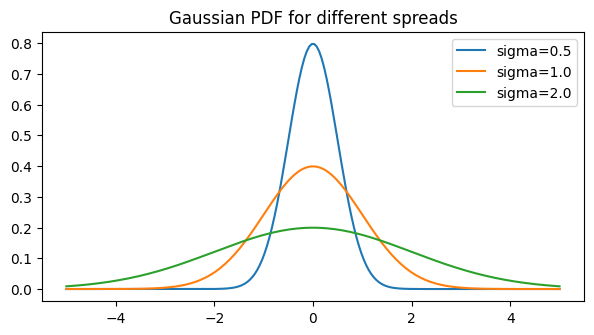

In [12]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

 LAB EXERCISE 4 — Simulate & plot distributions

1. Draw 10,000 samples from a **Poisson** with `mu=2` and print the sample mean.
2. Plot a **histogram** of those samples.
3. Plot the **Gaussian PDF** for `mu=0` with two different sigmas on one chart and observe how the spread changes the curve.

2.0061


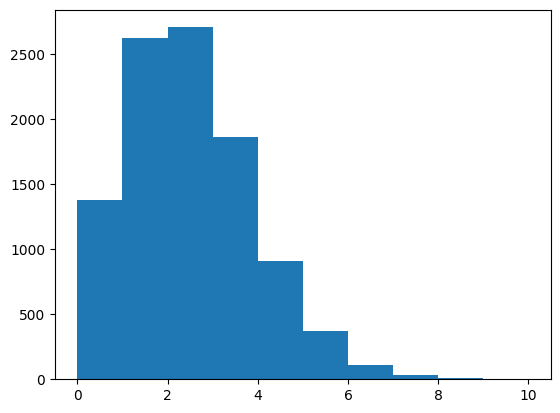

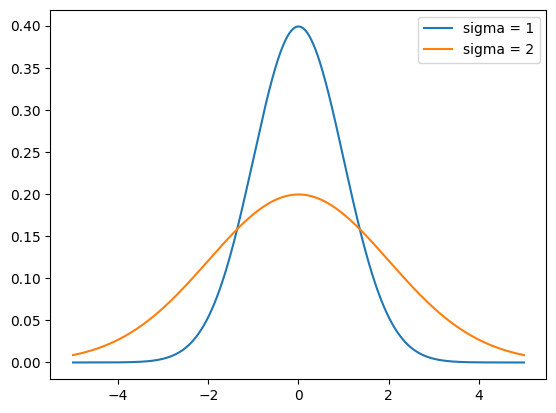

In [14]:
import numpy as np
import matplotlib.pyplot as plt
samples = np.random.poisson(2, 10000)
print(np.mean(samples))
plt.hist(samples)
plt.show()
x = np.linspace(-5, 5, 1000)
mu = 0
sigma1 = 1
sigma2 = 2
y1 = (1 / (sigma1 * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma1 ** 2))
y2 = (1 / (sigma2 * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma2 ** 2))
plt.plot(x, y1, label="sigma = 1")
plt.plot(x, y2, label="sigma = 2")
plt.legend()
plt.show()

#5. Entropy, KL divergence & mutual information

In [15]:
from scipy.stats import entropy
fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [16]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [17]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris
iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


 LAB EXERCISE 5 — Information theory

1. Compute the entropy (in bits) of a fair **4-sided die** and a fair **6-sided die**. Which is more uncertain?
2. Compute the KL divergence `D(P || Q)` for `P = [0.7, 0.3]` and `Q = [0.5, 0.5]`.
3. From the iris MI scores above, name the **most** and **least** informative feature.

In [18]:
import numpy as np
from scipy.stats import entropy
die4 = [1/4] * 4
die6 = [1/6] * 6
entropy4 = entropy(die4, base=2)
entropy6 = entropy(die6, base=2)
print("Entropy of 4-sided die:", entropy4)
print("Entropy of 6-sided die:", entropy6)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
kl = entropy(P, Q)
print("KL Divergence:", kl)
print("Most informative: petal length")
print("Least informative: sepal width")

Entropy of 4-sided die: 2.0
Entropy of 6-sided die: 2.584962500721156
KL Divergence: 0.08228287850505175
Most informative: petal length
Least informative: sepal width
